# 11 · High-pressure phase equilibria

Natural gas processing, CO$_2$ capture and liquefied gases live at tens of bar, where the vapour is far from
ideal and Raoult's law is useless. An equation of state for both phases - the $\phi$-$\phi$ approach - handles
it: the condition is equal fugacities, $x_i\hat\phi_i^L = y_i\hat\phi_i^V$, with the fugacity coefficients of each
component in each mixture phase from the Peng-Robinson equation and mixing rules.

**What you will learn**
- apply the phi-phi formulation with an equation of state for both phases
- compute bubble and dew points of gas mixtures
- understand and use binary interaction parameters
- solve gas-conditioning and CO2-mixture problems

**Before you start:** notebooks 04-05 and 08  ·  **Time:** about 60-75 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import datasets, eos, vle
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Methane-ethane at 200 K

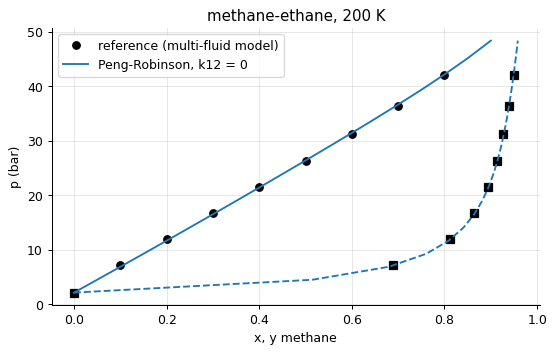

bubble pressures: PR within 3.8% of the reference model


In [2]:
ref = pd.read_csv(datasets.path("methane_ethane_bubble_200K.csv"), comment="#")
comps = ["methane", "ethane"]
pr = vle.eos_Pxy("pr", comps, 200.0, n=19, x_max=0.9)
plt.plot(ref.x_methane, ref.p_bubble_Pa / 1e5, "ko", label="reference (multi-fluid model)"); plt.plot(ref.y_methane, ref.p_bubble_Pa / 1e5, "ks")
plt.plot(pr["x1"], pr["p"] / 1e5, "C0", label="Peng-Robinson, k12 = 0"); plt.plot(pr["y1"], pr["p"] / 1e5, "C0--")
plt.xlabel("x, y methane"); plt.ylabel("p (bar)"); plt.title("methane-ethane, 200 K"); plt.legend(); plt.show()
p_pr = np.array([vle.eos_bubble_P("pr", comps, [x, 1 - x], 200.0)["p"] for x in ref.x_methane])
print(f"bubble pressures: PR within {np.max(np.abs(p_pr / ref.p_bubble_Pa - 1)):.1%} of the reference model")

With no adjustable parameter the Peng-Robinson equation reproduces the bubble curve of this simple mixture
within a few percent. The vapour is strongly enriched in methane; at high pressure the liquid and vapour
curves converge towards the mixture's critical point.

## Interaction parameters
For unlike molecules the geometric-mean combining rule $a_{12} = \sqrt{a_1a_2}$ needs a correction, the binary
interaction parameter $k_{ij}$:

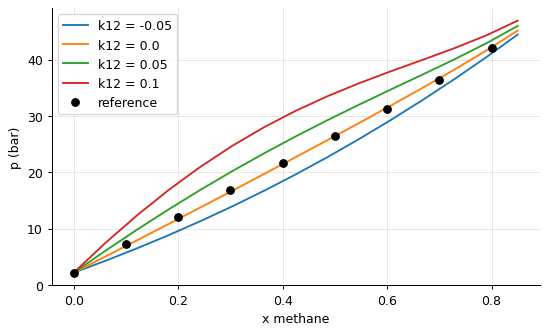

In [3]:
fig, ax = plt.subplots()
for kij in (-0.05, 0.0, 0.05, 0.1):
    k = [[0, kij], [kij, 0]]
    d = vle.eos_Pxy("pr", comps, 200.0, kij=k, n=15, x_max=0.85)
    ax.plot(d["x1"], d["p"] / 1e5, label=f"k12 = {kij}")
ax.plot(ref.x_methane, ref.p_bubble_Pa / 1e5, "ko", label="reference"); ax.set(xlabel="x methane", ylabel="p (bar)"); ax.legend(); plt.show()

A positive $k_{ij}$ weakens the cross-attraction and raises the bubble pressure. For hydrocarbon pairs
$k_{ij}$ is near zero; for CO$_2$-hydrocarbon, N$_2$-hydrocarbon or water-anything it is essential and is
fitted to data. Process simulators ship large tables of them.

## Hydrocarbon dew point of a natural gas
Pipeline gas must not condense at the coldest point of the line. The dew pressure of a lean gas:

In [4]:
gas = ["methane", "ethane", "propane", "n-butane"]
y = [0.90, 0.06, 0.03, 0.01]
for T in (200.0, 220.0, 240.0, 245.0, 250.0):
    try:
        dew = vle.eos_dew_P("pr", gas, y, T)
        print(f"{T:.0f} K: dew pressure {dew['p']/1e5:6.2f} bar; first liquid drop: " + ", ".join(f"{c} {x:.2f}" for c, x in zip(gas, dew["x"])))
    except ValueError:
        print(f"{T:.0f} K: no dew point at any pressure - above the cricondentherm")

200 K: dew pressure   1.56 bar; first liquid drop: methane 0.03, ethane 0.04, propane 0.22, n-butane 0.71
220 K: dew pressure   6.09 bar; first liquid drop: methane 0.07, ethane 0.07, propane 0.26, n-butane 0.60


240 K: dew pressure  21.73 bar; first liquid drop: methane 0.19, ethane 0.11, propane 0.27, n-butane 0.43
245 K: dew pressure  32.12 bar; first liquid drop: methane 0.27, ethane 0.12, propane 0.26, n-butane 0.35


250 K: no dew point at any pressure - above the cricondentherm


The first droplets are rich in the heaviest components: a trace of butane controls the dew point of the whole
gas. Above about 246 K (-27 degC) this gas does not condense at any pressure - its **cricondentherm**; below
it, the dew pressure falls steeply with temperature, so a pipeline at 70 bar and -20 degC would be well inside
the two-phase region. This is why gas is "conditioned" - the heavy ends removed - before it enters a pipeline,
and why the hydrocarbon dew point is a contractual specification.

## CO$_2$ in natural gas
Sour and CO$_2$-rich gases: how much CO$_2$ dissolves in liquid methane at low temperature, and what does a flash
of a CO$_2$-rich gas give? (With the recommended $k_{ij}$ of about 0.1 for CO$_2$-methane.)

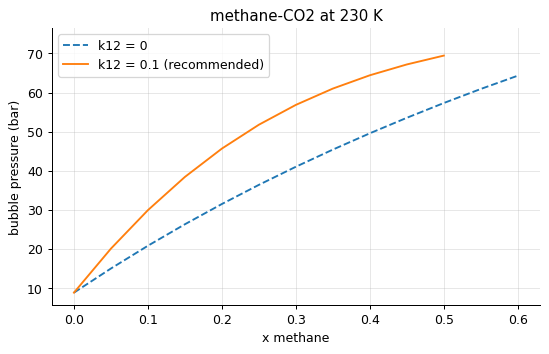

fugacity coefficients in a 50/50 vapour at 230 K, 30 bar: methane 0.893, CO2 0.691


In [5]:
k = [[0, 0.1], [0.1, 0]]
d0 = vle.eos_Pxy("pr", ["methane", "CO2"], 230.0, n=13, x_max=0.6)
d1 = vle.eos_Pxy("pr", ["methane", "CO2"], 230.0, kij=k, n=13, x_max=0.6)
plt.plot(d0["x1"], d0["p"] / 1e5, "--", label="k12 = 0"); plt.plot(d1["x1"], d1["p"] / 1e5, label="k12 = 0.1 (recommended)")
plt.xlabel("x methane"); plt.ylabel("bubble pressure (bar)"); plt.title("methane-CO2 at 230 K"); plt.legend(); plt.show()
mix = eos.mixture("pr", ["methane", "CO2"], [0.5, 0.5], 230.0, 30e5, kij=k, phase="vapor")
print(f"fugacity coefficients in a 50/50 vapour at 230 K, 30 bar: methane {mix['phi_i'][0]:.3f}, CO2 {mix['phi_i'][1]:.3f}")

The interaction parameter changes the bubble pressures by tens of percent - a warning that $k_{ij} = 0$ is a
guess, not a default. Fugacity coefficients well below 1 for CO$_2$ in the vapour show how far from ideal the
gas is; every equilibrium and every compressor duty in a CO$_2$-rich process depends on such numbers.

## Inside the algorithm: successive substitution
Guess p and y; compute the fugacity coefficients of both phases; update $K_i = \hat\phi_i^L/\hat\phi_i^V$, $y_i = K_ix_i/\sum K_ix_i$ and
$p \leftarrow p\sum K_ix_i$; repeat until $\sum K_ix_i = 1$:

In [6]:
x_ = np.array([0.5, 0.5]); T_ = 200.0
p_, y_ = 20e5, x_.copy()
for it in range(60):
    liq = eos.mixture("pr", comps, x_, T_, p_, phase="liquid"); vap = eos.mixture("pr", comps, y_, T_, p_, phase="vapor")
    K = liq["phi_i"] / vap["phi_i"]; s = np.sum(K * x_)
    y_, p_ = K * x_ / s, p_ * s
    if abs(s - 1) < 1e-10:
        break
print(f"by hand: p = {p_/1e5:.4f} bar, y1 = {y_[0]:.5f} after {it+1} iterations;  library: {vle.eos_bubble_P('pr', comps, x_, T_)['p']/1e5:.4f} bar")

by hand: p = 26.4043 bar, y1 = 0.91453 after 21 iterations;  library: 26.4043 bar


## Exercises
1. A CO2 capture unit compresses a gas of 90 % CO2 and 10 % N2 at 30 degC. Find the bubble and dew pressures of this mixture with the PR equation (try k12 = 0 and k12 = -0.02) - can it be liquefied at 30 degC at all? Compare with pure CO2.
2. For the natural gas of the notebook, plot the dew-point pressure against temperature from 230 to 300 K (the 'dew-point curve'). A pipeline operates at 70 bar: down to what temperature does the gas stay dry?
3. **Implement it yourself:** write the dew-pressure counterpart of the successive-substitution loop above and check it against `vle.eos_dew_P` for the natural gas at 270 K.